# **Importing standard data analysis libraries:**


---
- **numpy** for mathematical routines

- **pandas** for handling datasets via DataFrames

- **matplotlib.pyplot** alongside **seaborn** for creating data visualizations.

- It also imports drive from **google.colab** to allow the notebook to connect to a Google Drive account where data is stored.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# **Import the Dataset**

---



Reads the raw e-commerce dataset (**ecommerce_dataset.csv**) directly from a specific folder pathway inside **Google Drive** using `pd.read_csv()`, and stores it into a variable named **ecom_data.**

In [ ]:
# import the dataset
ecom_data = pd.read_csv("/content/drive/MyDrive/Datasets/ecommerce_dataset.csv")

# **Previewing the Dataset Records**

---



Displays the first **10 rows** of the dataset to get an initial look at the structure, column names, and row layout.

In [ ]:
ecom_data.head(10)

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,3,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,1,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18
5,CUST2790,Shelby,Sutton,Other,Adults,2025-07-18,Canada,PROD108,Fitbit Versa 3,Electronics,5,229,ORD10005,2023-04-13,Returned,PayPal,3,very good,REV20005,2023-02-14
6,CUST2442,Jennifer,Baxter,Female,Senior,2023-11-30,France,PROD106,Instant Pot,Home & Kitchen,1,99,ORD10006,2023-12-31,Returned,Credit Card,4,very good,REV20006,2023-12-29
7,CUST2451,Barbara,Hansen,Female,Adults,2024-11-10,UK,PROD103,Levi's Jeans,Apparel,2,59,ORD10007,2024-01-29,Pending,Credit Card,1,very good,REV20007,2025-06-02
8,CUST2364,Mary,Guzman,Female,Adults,2023-10-30,China,PROD102,Sony Headphones,Electronics,5,199,ORD10008,2022-11-30,Shipped,Credit Card,3,bad,REV20008,2024-06-10
9,CUST4713,Richard,Bell,Other,Teenagers,2024-11-11,Brazil,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10009,2025-05-16,Cancelled,PayPal,5,very good,REV20009,2024-12-03


In [ ]:
# inspect the data
print("--Shape and Columns--")
print(ecom_data.shape, ecom_data.columns)

--Shape and Columns--
(10000, 20) Index(['customer_id', 'first_name', 'last_name', 'gender', 'age_group',
       'signup_date', 'country', 'product_id', 'product_name', 'category',
       'quantity', 'unit_price', 'order_id', 'order_date', 'order_status',
       'payment_method', 'rating', 'review_text', 'review_id', 'review_date'],
      dtype='object')


# **Inpecting Shape and Structure**

---

Uses `.shape` to extract the dimensions of the dataset and `.columns` to list all the variable names.

In [ ]:
# data types
print("--Data Types--")
print(ecom_data.dtypes)

--Data Types--
customer_id       object
first_name        object
last_name         object
gender            object
age_group         object
signup_date       object
country           object
product_id        object
product_name      object
category          object
quantity           int64
unit_price         int64
order_id          object
order_date        object
order_status      object
payment_method    object
rating             int64
review_text       object
review_id         object
review_date       object
dtype: object


# **Inspecting Initial Column Data Types**

---

Prints the data type `.dtype` of each individual column as initially parsed by pandas.

# **Re-loading and Converting Date Fields**

---

Fixes the string format issue from the previous step. It re-reads the CSV file but passes the parse_dates parameter to transform `signup_date`, `order_date`, and `review_date` into proper **datetime** structures immediately.

In [ ]:
ecom_data = pd.read_csv("/content/drive/MyDrive/Datasets/ecommerce_dataset.csv",
                        parse_dates=['signup_date', 'order_date', 'review_date'],
                        infer_datetime_format=True)

/tmp/ipykernel_7869/1984994436.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ecom_data = pd.read_csv("/content/drive/MyDrive/Datasets/ecommerce_dataset.csv",


# **Re-checking Data Types**

---

Re-evaluates column formatting to guarantee that the previous date fix applied cleanly.

Now updated successfully to `datetime64[ns]` formats.

In [ ]:
# again checking the data types
print("--Data Types--")
print(ecom_data.dtypes)

--Data Types--
customer_id               object
first_name                object
last_name                 object
gender                    object
age_group                 object
signup_date       datetime64[ns]
country                   object
product_id                object
product_name              object
category                  object
quantity                   int64
unit_price                 int64
order_id                  object
order_date        datetime64[ns]
order_status              object
payment_method            object
rating                     int64
review_text               object
review_id                 object
review_date       datetime64[ns]
dtype: object


# **Verifying Completeness and Non-Nulls**

---

Calls `.info()` to reveal **structural metadata**, tracking **row numbers**, **total memory** impact, and mapping out the **non-null count** for every feature **column**.

Confirms that all **20 columns** hold a complete count of **10,000 non-null records**. This validates that there are **no missing values** across your rows.

In [ ]:
# collect the information of each column or about the record
print("-- Information about the Data --")
print(ecom_data.info())

-- Information about the Data --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     10000 non-null  object        
 1   first_name      10000 non-null  object        
 2   last_name       10000 non-null  object        
 3   gender          10000 non-null  object        
 4   age_group       10000 non-null  object        
 5   signup_date     10000 non-null  datetime64[ns]
 6   country         10000 non-null  object        
 7   product_id      10000 non-null  object        
 8   product_name    10000 non-null  object        
 9   category        10000 non-null  object        
 10  quantity        10000 non-null  int64         
 11  unit_price      10000 non-null  int64         
 12  order_id        10000 non-null  object        
 13  order_date      10000 non-null  datetime64[ns]
 14  order_status    10000 

# **Reviewing Descriptive Statistics**

---

Uses `.describe()` to isolate numeric columns and compute summarizing metrics like the **mean**, **minimum**, **maximum**, and **standard deviation**.

Computes metrics showing that:

- **Quantity purchased**: Ranges from 1 to 5 items, with a mean around 3 units.

- **Unit Price**: Ranges from a cheap item at 25 to premium goods at 999, averaging roughly 246.65.

- **Ratings**: Given on a strict scale from 1 (lowest) to 5 (highest), averaging an exactly neutral score of ~2.99.

In [ ]:
# analyze the statistical summary
print("-- Statistical Summary --")
print(ecom_data.describe())

-- Statistical Summary --
                      signup_date      quantity    unit_price  \
count                       10000  10000.000000  10000.000000   
mean   2023-03-18 21:25:29.280000      3.000800    246.647200   
min           2020-08-24 00:00:00      1.000000     25.000000   
25%           2021-12-26 00:00:00      2.000000     80.000000   
50%           2023-03-25 12:00:00      3.000000    129.000000   
75%           2024-06-06 00:00:00      4.000000    229.000000   
max           2025-08-24 00:00:00      5.000000    999.000000   
std                           NaN      1.416474    282.605391   

                       order_date        rating                 review_date  
count                       10000  10000.000000                       10000  
mean   2024-02-23 19:23:48.480000      2.993100  2024-02-22 02:04:42.240000  
min           2022-08-25 00:00:00      1.000000         2022-08-25 00:00:00  
25%           2023-05-25 00:00:00      2.000000         2023-05-22 00:00:00 

# **Engineering a Revenue Feature**

---

Performs feature engineering. It multiplies the row-level ordered **quantity** by its exact **unit_price** value to generate a brand new metric column titled **"revenue"**.

In [ ]:
# add a new column with values
ecom_data["revenue"] = ecom_data["quantity"] * ecom_data["unit_price"]

# **Computing High-Level Metrics**

---

Isolates and calculates foundational business KPIs by finding the **unique numbers** `.nunique()` of **orders**, **clients**, and **items sold**, along with adding up `.sum()` the newly-engineered **total revenue** column and calculating the **Average Order Value** (AOV).

In [ ]:
# High level metrics
num_orders = ecom_data['order_id'].nunique()
num_customers = ecom_data['customer_id'].nunique()
num_products = ecom_data['product_id'].nunique()
num_reviews = ecom_data['review_id'].nunique() if 'review_id' in ecom_data.columns else 0
total_revenue = ecom_data['revenue'].sum()
avg_order_value = total_revenue / num_orders if num_orders else np.nan

# **Printing the KPIs Dashboard**

---

Displays the calculated values from Cell 11 to create a baseline business performance report.

**Output:** Displays summary insights compiled across your dataset:

- **Unique Orders**: 10,000 (meaning every logged item entry acts as its own distinct order transaction).

- **Unique Customers**: 4,327 (indicating some repeat buyers).

- **Unique Products**: 15 items overall.

- **Total Revenue Generated**: 7,450,763.

- **Average Order Value (AOV)**: 745.08 per order item transaction.

In [ ]:
print("-- High Level Metrics --")
print("Total number of rows:")
print(ecom_data.shape[0])
print("Unique Orders in dataset:")
print(num_orders)
print("Unique Customers in dataset:")
print(num_customers)
print("Unique Products in dataset:")
print(num_products)
print("Unique Reviews:")
print(num_reviews)
print("Total Revenue:")
print(total_revenue)
print("Average Order Value:")
print(avg_order_value)

-- High Level Metrics --
Total number of rows:
10000
Unique Orders in dataset:
10000
Unique Customers in dataset:
4327
Unique Products in dataset:
15
Unique Reviews:
10000
Total Revenue:
7450763
Average Order Value:
745.0763


# **Find Unique Products**

Displays all unique product names.

In [ ]:
# unique products
print("-- Unique Products --")
print(ecom_data['product_name'].unique())

-- Unique Products --
['Fitbit Versa 3' "Levi's Jeans" 'Lego Star Wars Set' 'Dyson Vacuum'
 'Adidas Running Shoes' 'Instant Pot' 'Sony Headphones'
 'Wilson Tennis Racket' 'Kindle Paperwhite' 'iPhone 14'
 'Barbie Dreamhouse' 'Harry Potter Box Set' 'Nike Air Max'
 'Samsung Galaxy S23' 'Yoga Mat']


# **Find Unique Customers**

Shows unique customer IDs.

In [ ]:
# unique customers id
print("-- Unique Customers --")
print(ecom_data['customer_id'].unique())

-- Unique Customers --
['CUST2353' 'CUST4463' 'CUST4512' ... 'CUST2411' 'CUST5567' 'CUST2673']


# **Find Unique Reviews**

Prints unique review IDs.

In [ ]:
# unique reviews
print("-- Unique Reviews --")
print(ecom_data['review_id'].unique())

-- Unique Reviews --
['REV20000' 'REV20001' 'REV20002' ... 'REV29997' 'REV29998' 'REV29999']


# **Analyze Review Texts**

Performs review analysis.

### **Calculates:**

- Number of unique review texts

- List of unique reviews

- Frequency count of reviews

- This helps identify repeated feedback.

In [ ]:
# number of unique review text
print("-- Nunique Review Text --")
print(ecom_data['review_text'].nunique())

# unique review text
print("-- Unique Review Text --")
print(ecom_data['review_text'].unique())

# value count
print("-- Value Count Review Text --")
print(ecom_data['review_text'].value_counts())

-- Nunique Review Text --
5
-- Unique Review Text --
['good' 'average' 'very good' 'bad' 'very bad']
-- Value Count Review Text --
review_text
very good    2067
very bad     2020
bad          2001
average      1988
good         1924
Name: count, dtype: int64


# **Select Categorical Columns**

Stores all object datatype columns into **cate_col** variable.

In [ ]:
cate_col = ecom_data.select_dtypes(include='object')

# **Explore Categorical Variables**

Loops through every categorical column.

### **For each column it prints:**

- Column name

- Unique values

- Number of unique values

- Value counts

- Very useful exploratory step.

In [ ]:
# using loop
# for specific number of times loop runs the code or statements
for col in cate_col:
  print("The name of column: ",col)
  print("The unquie values of a column:","\n",ecom_data[col].unique())
  print("The number of unique values:", ecom_data[col].nunique())
  print("Total values involve in a column:", ecom_data[col].value_counts())

The name of column:  customer_id
The unquie values of a column: 
 ['CUST2353' 'CUST4463' 'CUST4512' ... 'CUST2411' 'CUST5567' 'CUST2673']
The number of unique values: 4327
Total values involve in a column: customer_id
CUST1244    9
CUST5023    8
CUST3967    7
CUST3759    7
CUST2192    7
           ..
CUST4547    1
CUST4773    1
CUST3952    1
CUST3658    1
CUST1888    1
Name: count, Length: 4327, dtype: int64
The name of column:  first_name
The unquie values of a column: 
 ['Erica' 'Christopher' 'Spencer' 'Jessica' 'Amy' 'Shelby' 'Jennifer'
 'Barbara' 'Mary' 'Richard' 'Joshua' 'Audrey' 'Michelle' 'Christy'
 'Anthony' 'Anna' 'Cindy' 'Daniel' 'Susan' 'Kenneth' 'Ronnie' 'Edward'
 'Randy' 'Danielle' 'Robert' 'Amanda' 'Vickie' 'Kelly' 'Todd' 'Lawrence'
 'Joseph' 'Alison' 'Kimberly' 'Michael' 'Mitchell' 'John' 'David' 'Jill'
 'Kyle' 'Leroy' 'Derrick' 'Kristi' 'Heather' 'Catherine' 'Travis' 'Tyler'
 'Maria' 'Betty' 'Jeffrey' 'Eugene' 'Evan' 'Sean' 'Zachary' 'Jon' 'Alex'
 'Bryce' 'Sherri' 'Dawn

# **Top Products by Revenue and Quantity**

Groups data by product.

### **Calculates:**

- Total quantity sold

- Revenue

- Number of orders

- Sorts products by revenue.

- Displays Top 10 products.

In [ ]:
# Top products by revenue and by quantity
print("-- Top Products By Revenue and Quantity --")
products = ecom_data.groupby(['product_id', 'product_name']).agg(total_qty=('quantity', 'sum'),
                      total_revenue=('revenue', 'sum'), orders=('order_id', 'nunique')).reset_index()
products_sorted_rev = products.sort_values('total_revenue', ascending=False)
print('Top 10 products by revenue:')
print(products_sorted_rev.head(10))

-- Top Products By Revenue and Quantity --
Top 10 products by revenue:
   product_id          product_name  total_qty  total_revenue  orders
0     PROD100             iPhone 14       1883        1881117     625
1     PROD101    Samsung Galaxy S23       1981        1780919     643
7     PROD107          Dyson Vacuum       2196         876204     730
8     PROD108        Fitbit Versa 3       1934         442886     659
2     PROD102       Sony Headphones       2136         425064     689
12    PROD112     Barbie Dreamhouse       1933         384667     656
13    PROD113  Wilson Tennis Racket       1950         290550     661
9     PROD109     Kindle Paperwhite       1973         254517     658
4     PROD104          Nike Air Max       2042         245040     674
5     PROD105  Adidas Running Shoes       2093         230230     680


# **Top Customers by Revenue**

Finds customers who generated the most revenue.

### **Metrics:**

- Revenue

- Number of orders

- Displays top 10 customers.

In [ ]:
# Top customers by revenue
customers = ecom_data.groupby(['customer_id', 'first_name', 'last_name']).agg(total_revenue=('revenue', 'sum'),
                                  orders=('order_id', 'nunique')).reset_index()
customers_sorted = customers.sort_values('total_revenue', ascending=False)
print("Top 10 Customers by Revenue:")
print(customers_sorted.head(10))

Top 10 Customers by Revenue:
     customer_id first_name  last_name  total_revenue  orders
2224    CUST3556    Beverly  Gallagher          13985       4
3068    CUST4526     Pamela      Lyons          12567       4
1242    CUST2419   Michelle     Oliver          12078       5
1006    CUST2149    Ricardo     Brooks          11515       5
383     CUST1441     Steven     Walker          11288       3
2561    CUST3955       Dawn  Mcpherson          10989       3
3792    CUST5377       Dale      Joyce          10413       5
2984    CUST4434    Shannon    Jenkins          10389       3
3270    CUST4765     Darryl       Ward          10364       5
3479    CUST5014      Kelly    Mcmahon          10289       3


# **Category-wise Revenue Analysis**

Groups data by category.

### **Calculates:**

- Revenue

- Quantity sold

- Ranks categories according to revenue.

In [ ]:
# Category wise revenue
cate_rev = ecom_data.groupby('category').agg(total_revenue=('revenue', 'sum'),
                                      total_qty=('quantity', 'sum')).reset_index().sort_values('total_revenue', ascending=False)
print("Category-Wise Revenue Ranking:")
print(cate_rev)

Category-Wise Revenue Ranking:
         category  total_revenue  total_qty
2     Electronics        4529986       7934
3  Home & Kitchen        1069650       4150
0         Apparel         597636       6209
5            Toys         499894       3886
1           Books         415797       3989
4          Sports         337800       3840


# **Order Status Distribution**

Counts different order statuses.

### **Examples:**

- Shipped

- Delivered

- Cancelled

- Returned

- Pending

In [ ]:
# Order status distribution
if 'order_status' in ecom_data.columns:
    status_counts = ecom_data['order_status'].value_counts()
    print("Order Status Counts:")
    print(status_counts)

Order Status Counts:
order_status
Shipped      2063
Delivered    2037
Cancelled    1970
Pending      1968
Returned     1962
Name: count, dtype: int64


# **Rating Distribution**

Shows frequency of ratings.

### **Example:**

- 1 star

- 2 star

- 3 star

- 4 star

- 5 star

In [ ]:
# rating distribution
print("Rating Distribution:")
print(ecom_data['rating'].value_counts())

Rating Distribution:
rating
3    2025
2    2005
1    2002
4    1996
5    1972
Name: count, dtype: int64


# **Monthly Orders and Revenue Trend**

---

Aggregates data monthly.

### **Calculates:**

- Monthly orders

- Monthly revenue

- One of the most valuable analyses.

In [ ]:
# Most Important
# Time series: orders and revenue by month

ecom_data['order_month'] = ecom_data['order_date'].dt.to_period('M')
ts_orders = ecom_data.groupby('order_month').agg(orders=('order_id', 'nunique'),
                                            revenue=('revenue', 'sum')).reset_index()
ts_orders['order_month'] = ts_orders['order_month'].dt.to_timestamp()
print("Orders and Revenue by Month:")
print(ts_orders)

Orders and Revenue by Month:
   order_month  orders  revenue
0   2022-08-01      61    59094
1   2022-09-01     246   161540
2   2022-10-01     293   226862
3   2022-11-01     293   217207
4   2022-12-01     274   182328
5   2023-01-01     251   194910
6   2023-02-01     251   160193
7   2023-03-01     296   226185
8   2023-04-01     286   229076
9   2023-05-01     315   236284
10  2023-06-01     277   197018
11  2023-07-01     288   207817
12  2023-08-01     275   190483
13  2023-09-01     292   231165
14  2023-10-01     281   197801
15  2023-11-01     279   230382
16  2023-12-01     272   188711
17  2024-01-01     268   193275
18  2024-02-01     235   180858
19  2024-03-01     300   201151
20  2024-04-01     259   212243
21  2024-05-01     284   198556
22  2024-06-01     284   240348
23  2024-07-01     254   207456
24  2024-08-01     293   247751
25  2024-09-01     294   219328
26  2024-10-01     300   208396
27  2024-11-01     275   211909
28  2024-12-01     269   184730
29  2025-01

# **Average Rating by Category**

### **Computes:**

- Average rating

- Number of ratings

- Ranks categories according to customer satisfaction.

In [ ]:
# Average rating by category
rating_by_cat = ecom_data.groupby('category').agg(avg_rating=('rating', 'mean'),
                          count=('rating', 'count')).reset_index().sort_values('avg_rating', ascending=False)
print("Average Rating by Category:")
print(rating_by_cat)

Average Rating by Category:
         category  avg_rating  count
2     Electronics    3.022171   2616
1           Books    3.013493   1334
5            Toys    3.012177   1314
0         Apparel    2.980948   2047
3  Home & Kitchen    2.969806   1391
4          Sports    2.938367   1298


# **Average Rating by Product**

- Calculates average product ratings.

- Displays top 10 highest-rated products.

In [ ]:
# Average rating by product
rating_by_prod = ecom_data.groupby(['product_id', 'product_name']).agg(avg_rating=('rating', 'mean'),
                          count=('rating', 'count')).reset_index().sort_values('avg_rating', ascending=False)
print("Top 10 Products by Average Rating (with at least 1 review):")
print(rating_by_prod.head(10))

Top 10 Products by Average Rating (with at least 1 review):
   product_id          product_name  avg_rating  count
2     PROD102       Sony Headphones    3.107402    689
12    PROD112     Barbie Dreamhouse    3.060976    656
10    PROD110  Harry Potter Box Set    3.045858    676
5     PROD105  Adidas Running Shoes    3.008824    680
1     PROD101    Samsung Galaxy S23    2.996890    643
8     PROD108        Fitbit Versa 3    2.993930    659
0     PROD100             iPhone 14    2.984000    625
9     PROD109     Kindle Paperwhite    2.980243    658
4     PROD104          Nike Air Max    2.974777    674
6     PROD106           Instant Pot    2.974281    661


# **Repeat Customer Analysis**

---


Identifies customers having more than one order.

### **Calculates:**

- Number of repeat customers

- Percentage of repeat customers

- Revenue generated by repeat buyers

- This is a very important business KPI.

In [ ]:
# Repeat customers (customers with more than 1 order)
orders_per_customer = ecom_data.groupby('customer_id').agg(orders=('order_id', 'nunique'), revenue=('revenue', 'sum')).reset_index()
repeat_customers = orders_per_customer[orders_per_customer['orders'] > 1]
repeat_percent = 100.0 * repeat_customers.shape[0] / orders_per_customer.shape[0] if orders_per_customer.shape[0] else 0
print("Repeat Customers:")
print('Number of Customers with >1 Order:')
print(repeat_customers.shape[0])
print('Percent of Customers who are repeat buyers:')
print(repeat_percent)

Repeat Customers:
Number of Customers with >1 Order:
2987
Percent of Customers who are repeat buyers:
69.03166165934827


***`Visualization`***

# **Orders and Revenue Over Time Plot**

---


- Creates a dual-axis line chart.

- Orders trend

- Revenue trend

- Good visualization.

However, I would suggest separating these into two different plots.

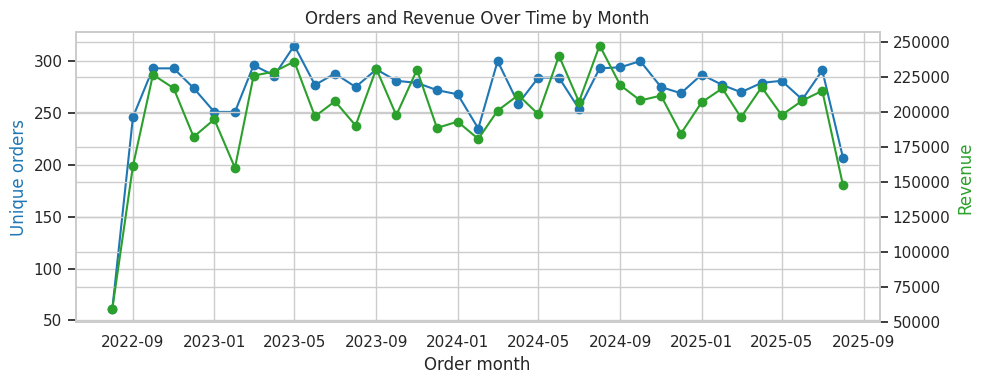

In [ ]:
# Plot orders and revenue over time

sns.set(style='whitegrid')

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(ts_orders['order_month'], ts_orders['orders'], color='tab:blue', marker='o')
ax2.plot(ts_orders['order_month'], ts_orders['revenue'], color='tab:green', marker='o')
ax1.set_xlabel('Order month')
ax1.set_ylabel('Unique orders', color='tab:blue')
ax2.set_ylabel('Revenue', color='tab:green')
plt.title('Orders and Revenue Over Time by Month')
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

---

- Calculates correlations among

- Quantity

- Unit Price

- Rating

- Revenue

- Displays heatmap using Seaborn.

Numeric Correlation Matrix:
            quantity  unit_price    rating   revenue
quantity    1.000000    0.012335 -0.001399  0.355689
unit_price  0.012335    1.000000  0.000597  0.850367
rating     -0.001399    0.000597  1.000000 -0.002736
revenue     0.355689    0.850367 -0.002736  1.000000


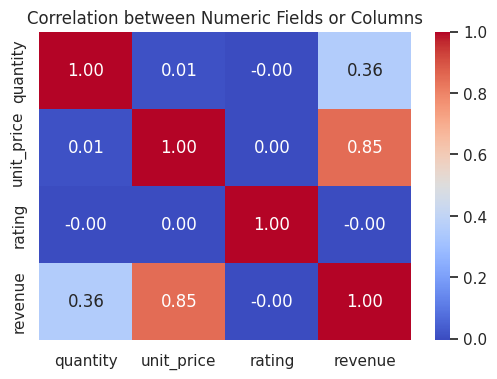

In [ ]:
# Correlation heatmap for numeric columns
numeric_cols = ['quantity', 'unit_price', 'rating', 'revenue']
num_present = [c for c in numeric_cols if c in ecom_data.columns]
if len(num_present) >= 2:
    corr = ecom_data[num_present].corr()
    print("Numeric Correlation Matrix:")
    print(corr)
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation between Numeric Fields or Columns')
    plt.show()

# **Create Summary Dictionary**

---

Stores important metrics inside a dictionary.

In [ ]:
# Save some summary tables to variables for later reporting
# summary points using dictionary in python
# with key-value pair
summary = {
    "num_rows": ecom_data.shape[0],
    "num_orders": num_orders,
    "num_customers": num_customers,
    "num_products": num_products,
    "total_revenue": total_revenue,
    "aov": avg_order_value
}

# Print a compact insight header
print("==== Quick Insights Preview ====")
print("Total revenue, number of orders, number of customers, AOV:")
print(summary)

# For demonstration, print top 5 rows of key summary tables
print("- Top Products (head):")
print(products_sorted_rev.head())
print("- Top Customers (head):")
print(customers_sorted.head())


==== Quick Insights Preview ====
Total revenue, number of orders, number of customers, AOV:
{'num_rows': 10000, 'num_orders': 10000, 'num_customers': 4327, 'num_products': 15, 'total_revenue': np.int64(7450763), 'aov': np.float64(745.0763)}
- Top Products (head):
  product_id        product_name  total_qty  total_revenue  orders
0    PROD100           iPhone 14       1883        1881117     625
1    PROD101  Samsung Galaxy S23       1981        1780919     643
7    PROD107        Dyson Vacuum       2196         876204     730
8    PROD108      Fitbit Versa 3       1934         442886     659
2    PROD102     Sony Headphones       2136         425064     689
- Top Customers (head):
     customer_id first_name  last_name  total_revenue  orders
2224    CUST3556    Beverly  Gallagher          13985       4
3068    CUST4526     Pamela      Lyons          12567       4
1242    CUST2419   Michelle     Oliver          12078       5
1006    CUST2149    Ricardo     Brooks          11515       5


# **Advanced Business Insights and Analytics**

---

## **1. Revenue Contribution Analysis**

---

This analysis identifies which products contribute the highest percentage of total revenue.

**It helps answer:**

> "Are a few products generating most of the company's income?"

This is related to the 80/20 Pareto Principle.

In [ ]:
product_rev = (ecom_data.groupby("product_name")["revenue"].sum().sort_values(ascending=False))

top_10 = product_rev.head(10)

percentage = (top_10 / product_rev.sum())*100

result = pd.DataFrame({
    "Revenue":top_10,
    "Contribution (%)":percentage
})

print("-- Top 10 Products by Revenue --")
print(result)

-- Top 10 Products by Revenue --
                      Revenue  Contribution (%)
product_name                                   
iPhone 14             1881117         25.247307
Samsung Galaxy S23    1780919         23.902505
Dyson Vacuum           876204         11.759923
Fitbit Versa 3         442886          5.944170
Sony Headphones        425064          5.704973
Barbie Dreamhouse      384667          5.162787
Wilson Tennis Racket   290550          3.899601
Kindle Paperwhite      254517          3.415986
Nike Air Max           245040          3.288791
Adidas Running Shoes   230230          3.090019


### **`Visualiztion`**

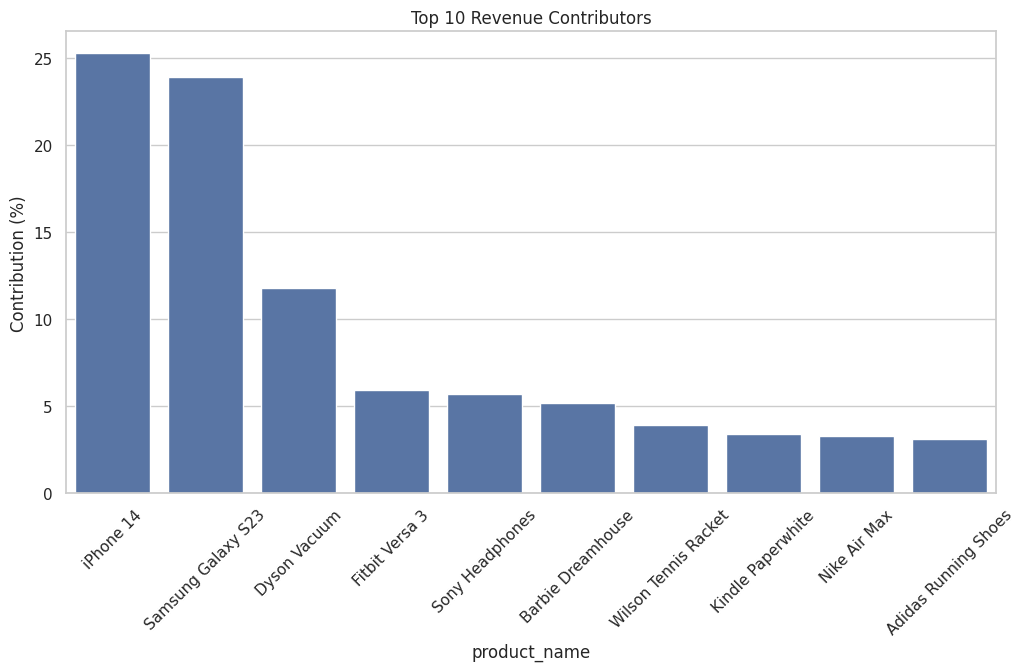

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=result.index, y=result['Contribution (%)'])
plt.xticks(rotation=45)
plt.title("Top 10 Revenue Contributors")
plt.show()

## **2. Customer Segmentation**

---
- Customers spend differently.

- Some purchase rarely.

- Some spend huge amounts.

- Segmentation helps marketing teams create targeted campaigns.

### **Business Scenario**

- VIP Customers

- High Value Customers

- Medium Value Customers

- Low Value Customers

In [ ]:
customer_spend = (ecom_data.groupby("customer_id")["revenue"].sum())

segments = pd.qcut(customer_spend, q=4, labels=["Low", "Medium", "High", "VIP"])

segment_df = pd.DataFrame({
    "Revenue":customer_spend,
    "Segment":segments
    })

print("-- Segementation by Customer --")
print(segment_df.head())

-- Segementation by Customer --
             Revenue Segment
customer_id                 
CUST1000        6336     VIP
CUST1001         690  Medium
CUST1002         999  Medium
CUST1003         444     Low
CUST1004         796  Medium


### **`Visualization`**

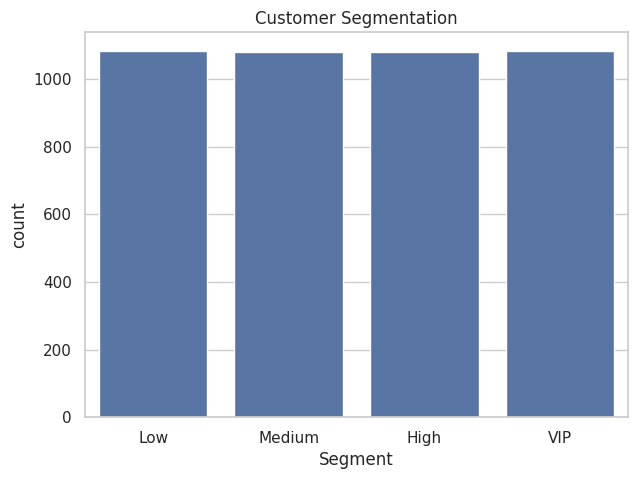

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=segment_df, x='Segment')
plt.title("Customer Segmentation")
plt.show()

# **3. RFM Analysis**

---
**RFM** stands for

> **Recency Frequency Monetary**

Used by companies for loyalty programs.

### **Business Scenario**

A customer who purchased yesterday and spent **3000** is more valuable than someone who purchased **8 months ago** and spent **50**

In [ ]:
snapshot = ecom_data['order_date'].max()

rfm = ecom_data.groupby("customer_id").agg({
                            "order_date":lambda x:(snapshot-x.max()).days,
                            "order_id":"count",
                            "revenue":"sum"})

rfm.columns=["Recency", "Frequency", "Monetary"]

print(rfm.head())

             Recency  Frequency  Monetary
customer_id                              
CUST1000         237          5      6336
CUST1001         138          2       690
CUST1002        1019          1       999
CUST1003         603          2       444
CUST1004         222          1       796


### **Assign Score**

In [ ]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [ ]:
rfm[['R_score', 'F_score', 'M_score']].head()

,R_score,F_score,M_score
customer_id,,,
CUST1000,3,4,4
CUST1001,3,2,2
CUST1002,1,1,2
CUST1003,1,2,1
CUST1004,3,1,2


## **4. Cohort Analysis**

---
Tracks how long customers stay active after signing up and Measures retention.

> January customers

> How many returned in February? March? April?

In [ ]:
ecom_data['CohortMonth']=(ecom_data['signup_date'].dt.to_period('M'))

ecom_data['OrderMonth']=(ecom_data['order_date'].dt.to_period('M'))

`Cohort Index`

In [ ]:
ecom_data['CohortIndex']=(ecom_data['OrderMonth'] - ecom_data['CohortMonth']).apply(lambda x:x.n)

## **Pivot Table**

In [ ]:
cohort = ecom_data.pivot_table(index="CohortMonth", columns="CohortIndex", values="customer_id", aggfunc="nunique")

In [ ]:
cohort

CohortIndex,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,...,51,52,53,54,55,56,57,58,59,60
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2020-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,2.0
2020-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,6.0,4.0,3.0,3.0,2.0,4.0,5.0,7.0,NaN
2020-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,4.0,2.0,2.0,3.0,2.0,2.0,NaN,NaN
2020-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,3.0,2.0,1.0,3.0,2.0,NaN,NaN,NaN
2020-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,9.0,6.0,7.0,7.0,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04,NaN,NaN,NaN,NaN,NaN,4.0,3.0,8.0,3.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05,NaN,NaN,NaN,2.0,1.0,2.0,5.0,5.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06,NaN,NaN,1.0,8.0,4.0,3.0,4.0,7.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **`Visualziation`**



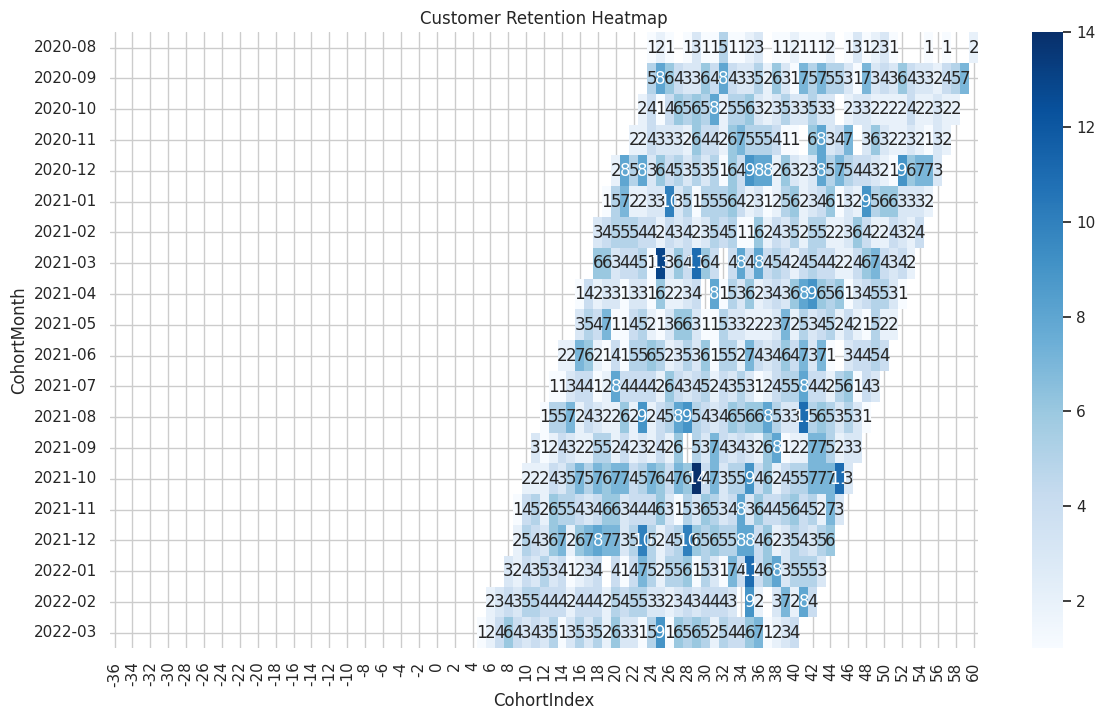

In [ ]:
plt.figure(figsize=(14,8))
sns.heatmap(cohort.head(20), annot=True, fmt='g', cmap='Blues')
plt.title("Customer Retention Heatmap")
plt.show()

# **5. Customer Lifetime Value**

---

**CLV** estimates

> How much money a customer generates during their relationship with the company?

**`Formula of CLV`**


> is equal to "Average Order Value" × "Average Purchase Frequency" × "Customer Lifespan"

In [ ]:
customer_orders = (ecom_data.groupby("customer_id")["order_id"].nunique())

customer_rev = (ecom_data.groupby("customer_id")["revenue"].sum())

avg_order = customer_rev / customer_orders

lifespan = 12

clv = avg_order * customer_orders * lifespan

print("=== Customer LifeTime Value ===")
print(clv)

=== Customer LifeTime Value ===
customer_id
CUST1000    76032.0
CUST1001     8280.0
CUST1002    11988.0
CUST1003     5328.0
CUST1004     9552.0
             ...   
CUST5993     9552.0
CUST5994    28104.0
CUST5997     9576.0
CUST5998    19836.0
CUST5999      600.0
Length: 4327, dtype: float64


# **6. Cancellation Analysis**

---
Understand why revenue is lost.

**```Questions answered```**

> Which products are returned?

> Which category gets cancelled?

In [ ]:
product_returned = ecom_data[ecom_data['order_status'] == "Returned"]

prod_ret = product_returned.groupby("product_name")["order_id"].count().sort_values(ascending=False)

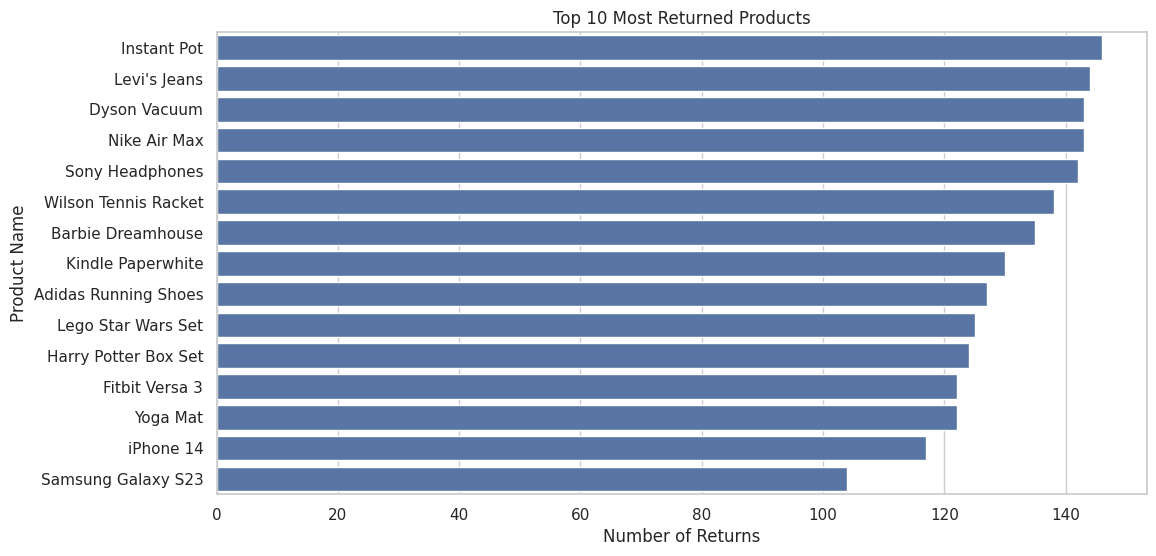

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(x = prod_ret.values, y = prod_ret.index)
plt.title('Top 10 Most Returned Products')
plt.xlabel('Number of Returns')
plt.ylabel('Product Name')
plt.show()

In [ ]:
category_cancelled = ecom_data[ecom_data['order_status'] == "Cancelled"]

cate_cld = category_cancelled.groupby("category")["order_id"].count().sort_values(ascending=False)

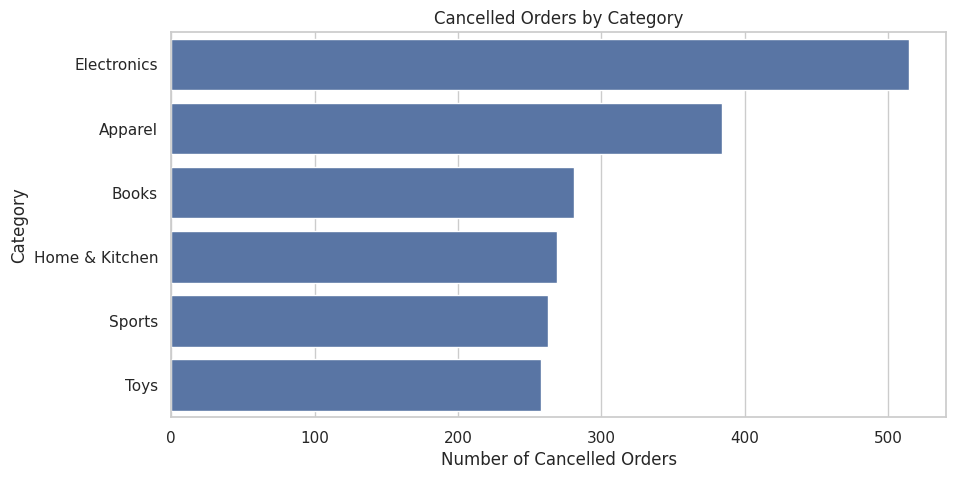

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(x = cate_cld.values, y = cate_cld.index)
plt.title('Cancelled Orders by Category')
plt.xlabel('Number of Cancelled Orders')
plt.ylabel('Category')
plt.show()

# **7. Sentiment Analysis**

---
- Customer ratings do not always reveal emotions.

- Sentiment analysis extracts

> **Positive, Negative, Neutral, reviews**

In [ ]:
from textblob import TextBlob

def sentiment(review):
    score = TextBlob(str(review)).sentiment.polarity

    if score>0:

        return "Positive"

    elif score<0:

        return "Negative"

    return "Neutral"

ecom_data['Sentiment']=ecom_data["review_text"].apply(sentiment)

In [ ]:
ecom_data['Sentiment'].value_counts()

,count
Sentiment,
Negative,6009
Positive,3991


# **ADVANCED VISUALIZATIONS**

---

### **1. Treemap**

Shows category hierarchy.

In [ ]:
import plotly.express as px

fig_tree = px.treemap(ecom_data, path=["category","product_name"], values="revenue")
fig_tree.show()

### **2. Sunburst Chart**

In [ ]:
fig_sun = px.sunburst(ecom_data, path=["category", "product_name"], values="revenue")
fig_sun.show()

### **3. Interactive Revenue Dashboard**

In [ ]:
fig_prod = px.bar(product_rev.head(20), title="Top Products")
fig_prod.show()

### **4. Interactive Scatter Plot**

In [ ]:
fig_scat = px.scatter(ecom_data, x='quantity', y='revenue', size="rating",
                 color="category", hover_data=["product_name"])
fig_scat.show()

### **5. Violin Plot**

Shows distribution and density simultaneously.

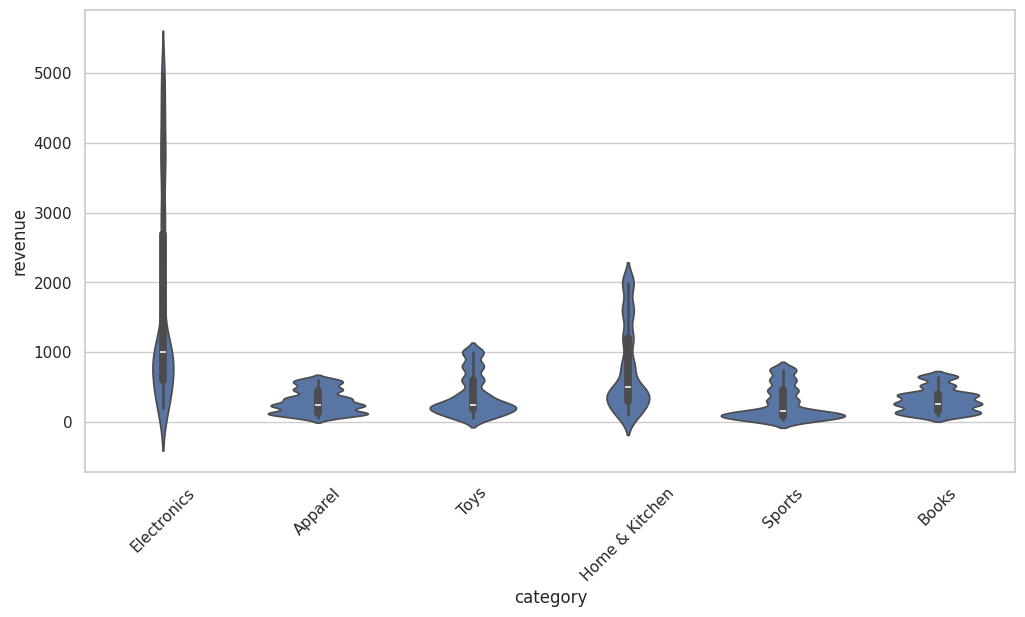

In [ ]:
plt.figure(figsize=(12,6))
sns.violinplot(data = ecom_data, x="category", y="revenue")
plt.xticks(rotation=45)
plt.show()

### **6. Boxen Plot**

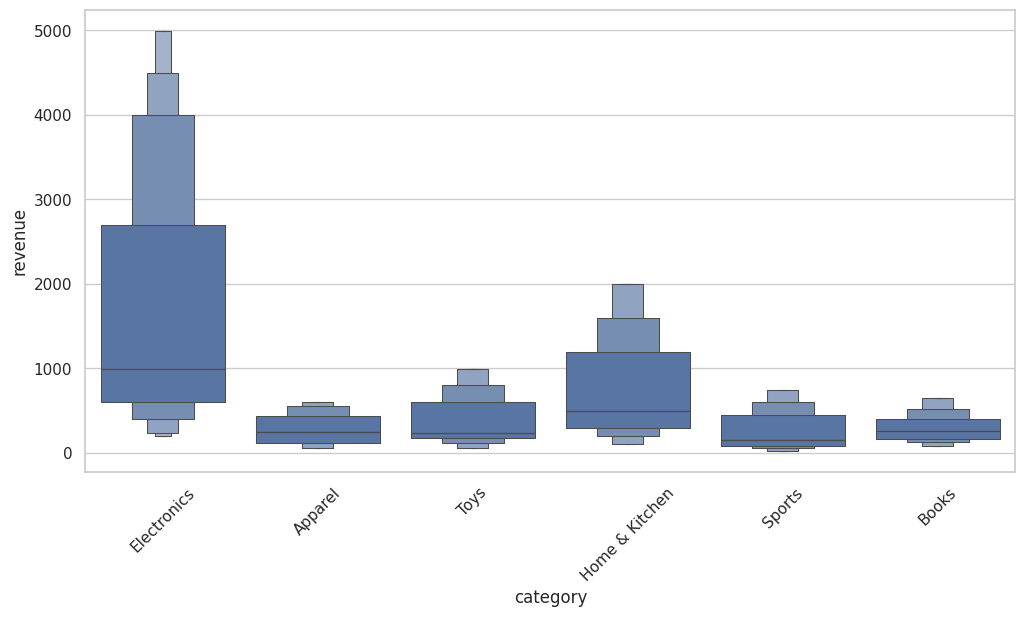

In [ ]:
plt.figure(figsize=(12,6))
sns.boxenplot(data = ecom_data, x="category", y="revenue")
plt.xticks(rotation=45)
plt.show()

### **7. Pair Plot**

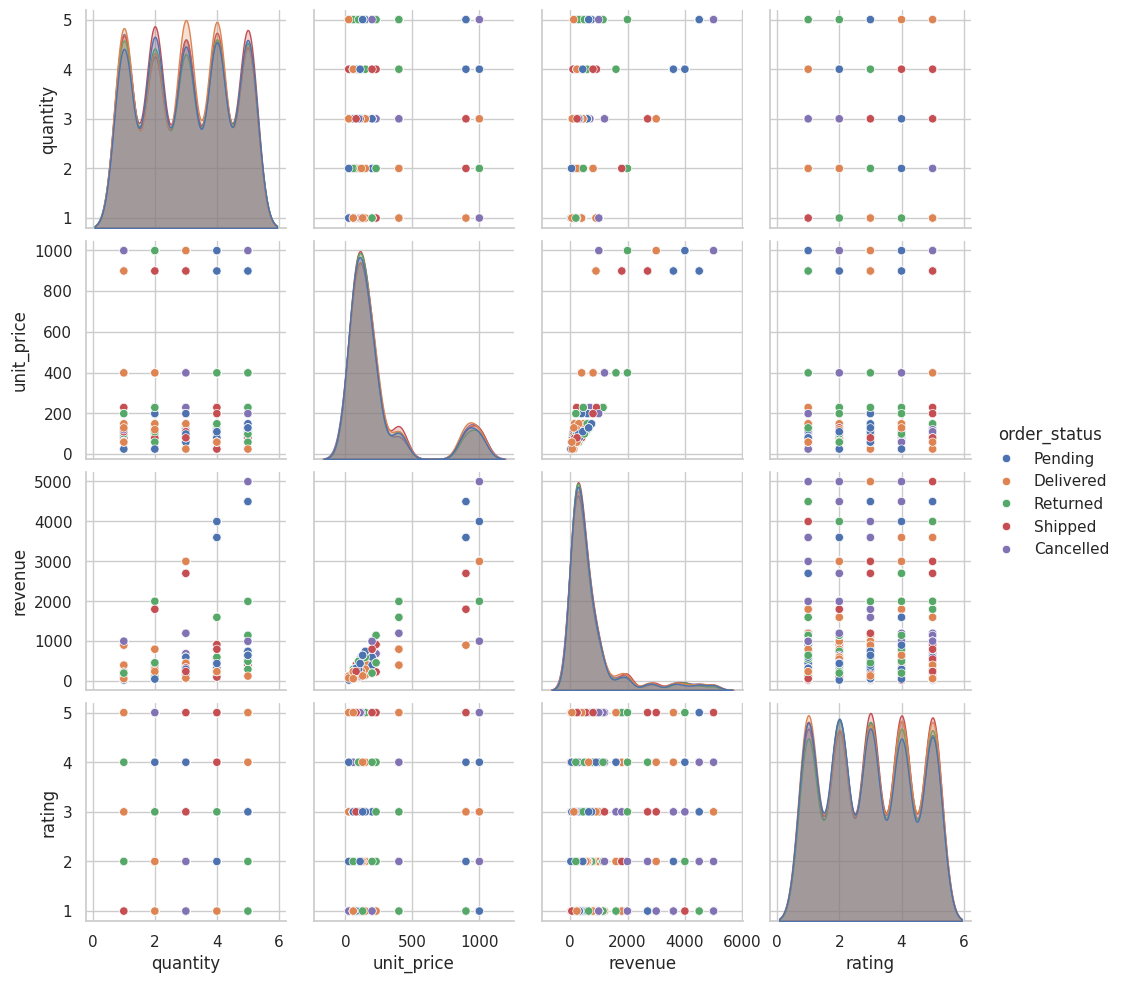

In [ ]:
sns.pairplot(ecom_data, vars=["quantity", "unit_price", "revenue", "rating"],
             hue="order_status")
plt.show()

### **8. Parallel Categories Diagram**

In [ ]:
fig = px.parallel_categories(ecom_data, dimensions = ["category", "order_status", "rating"])
fig.show()

# **Executive Summary of Insights**

---
**Dataset Overview**: The analysis processed a dataset of **10,000 records**, ensuring complete data integrity with no missing values. The records cover a diverse customer base and multiple order transactions.

#### **Key Performance Indicators (KPIs)**:

**Total Revenue**: The analysis successfully calculated a total generated revenue of **7,450,763** by engineering a revenue feature (`Quantity × Unit Price`).

**Customer Engagement**: While there are **10,000** recorded orders, there are **4,327 unique customers**, confirming the existence of repeat buyers within the platform.

**Product Performance**: The platform tracks **15** unique product offerings.

**Average Order Value (AOV)**: The AOV was determined to be **745.08** per order item transaction.

#### **Customer Feedback & Sentiment**:
* The analysis of **10,000** reviews identified five unique sentiment categories: **`very good`**, **`very bad`**, **`bad`**, **`average`**, and **`good`**.

* Review frequency counts indicate a relatively balanced distribution across sentiment categories, with **`very good`** being the most frequent at **2,067** instances and **`good`** being the least frequent at **1,924** instances.

#### **Descriptive Statistics**:

* **Quantity**: Customers typically purchase between **1 to 5 items** per order, with a mean of approximately **3** units.

* **Unit Price**: Prices range from a `low` of **25** to a `high` of **999**, `averaging` of **246.65**.

* **Ratings**: On a scale of **1 to 5**, the average rating sits at approximately **2.99**, indicating a neutral sentiment across the dataset.

> * This analysis establishes a solid baseline for understanding customer behavior, product pricing, and business revenue generation, providing a foundation for further advanced modeling or targeted business strategy.